In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

PASTA = "/content/drive/MyDrive/CFEM Minas Gerais"

os.makedirs(f"{PASTA}/graficos",          exist_ok=True)
os.makedirs(f"{PASTA}/dados_processados", exist_ok=True)

print(f"✅ Drive montado. Pasta de trabalho:")
print(f"   {PASTA}")
print(f"   Arquivos disponíveis: {os.listdir(PASTA)}")


Mounted at /content/drive
✅ Drive montado. Pasta de trabalho:
   /content/drive/MyDrive/CFEM Minas Gerais
   Arquivos disponíveis: ['CFEM_Arrecadacao_2022_2026.csv', 'CFEM_Arrecadacao_2017_2021.xlsx', 'Untitled0.ipynb', 'graficos', 'dados_processados']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

df_mg = pd.read_csv(f"{PASTA}/dados_processados/cfem_mg_limpo.csv")

df_mg['Data'] = pd.to_datetime(
    df_mg['Ano'].astype(str) + '-' + df_mg['Mês'].astype(str).str.zfill(2) + '-01'
)
print(f"Registros MG: {len(df_mg):,}")
print(f"Período: {df_mg['Data'].min().date()} → {df_mg['Data'].max().date()}")


Registros MG: 192,898
Período: 2017-01-01 → 2026-05-01


In [ ]:
anual = df_mg.groupby('Ano')['ValorRecolhido'].sum().reset_index()
anual['Bi']   = anual['ValorRecolhido'] / 1e9
anual['Var%'] = anual['Bi'].pct_change() * 100

print("Arrecadação CFEM anual — Minas Gerais:")
print(anual[['Ano','Bi','Var%']].to_string(index=False))

total_1721 = df_mg[df_mg['Periodo']=='2017-2021']['ValorRecolhido'].sum()
total_2226 = df_mg[df_mg['Periodo']=='2022-2026']['ValorRecolhido'].sum()
print(f"\nTotal 2017-2021: R$ {total_1721/1e9:.2f} bilhões")
print(f"Total 2022-2026: R$ {total_2226/1e9:.2f} bilhões")
print(f"Variação entre períodos: {(total_2226/total_1721-1)*100:+.1f}%")


Arrecadação CFEM anual — Minas Gerais:
 Ano       Bi       Var%
2017 0.777799        NaN
2018 1.311278  68.588166
2019 1.834443  39.897371
2020 2.364548  28.897292
2021 4.602946  94.664989
2022 3.117768 -32.265818
2023 3.180396   2.008755
2024 3.362425   5.723471
2025 3.571565   6.219897
2026 1.123258 -68.549968

Total 2017-2021: R$ 10.89 bilhões
Total 2022-2026: R$ 14.36 bilhões
Variação entre períodos: +31.8%


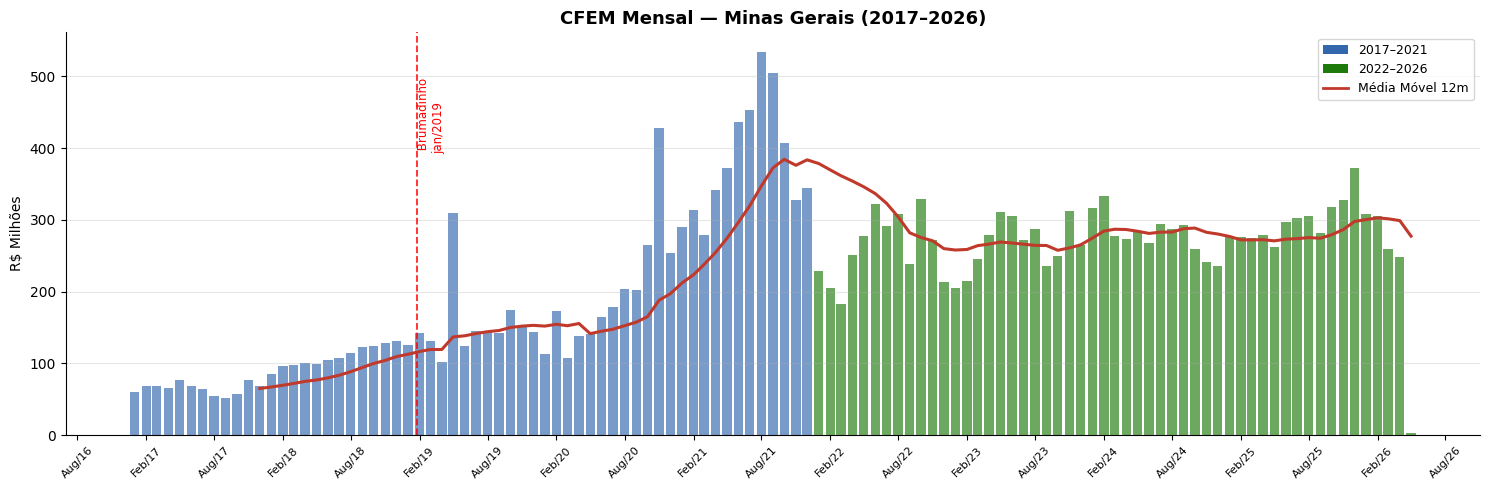

Gráfico salvo no Drive ✅


In [ ]:
mensal = df_mg.groupby('Data')['ValorRecolhido'].sum().reset_index()
mensal.columns = ['Data','Total']
mensal['MM12'] = mensal['Total'].rolling(12).mean()   # média móvel 12 meses

ROMPIMENTO = pd.Timestamp('2019-01-25')

fig, ax = plt.subplots(figsize=(15, 5))
cores = ['#3266ad' if d.year <= 2021 else '#1E7A0A' for d in mensal['Data']]
ax.bar(mensal['Data'], mensal['Total']/1e6, width=25, color=cores, alpha=0.65,
       label='Arrecadação mensal (R$ mi)')
ax.plot(mensal['Data'], mensal['MM12']/1e6, color='#C0392B',
        linewidth=2.2, label='Média Móvel 12 meses', zorder=3)

ax.axvline(ROMPIMENTO, color='red', linestyle='--', linewidth=1.3, alpha=0.85)
ax.text(ROMPIMENTO, mensal['Total'].max()/1e6 * 0.93,
        ' Brumadinho\njan/2019', color='red', fontsize=8.5, rotation=90, va='top')

ax.set_title('CFEM Mensal — Minas Gerais (2017–2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('R$ Milhões', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, fontsize=8)
ax.legend(handles=[
    mpatches.Patch(facecolor='#3266ad', label='2017–2021'),
    mpatches.Patch(facecolor='#1E7A0A', label='2022–2026'),
    plt.Line2D([0],[0], color='#C0392B', linewidth=2, label='Média Móvel 12m'),
], fontsize=9)
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb3_serie_mensal_mg.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


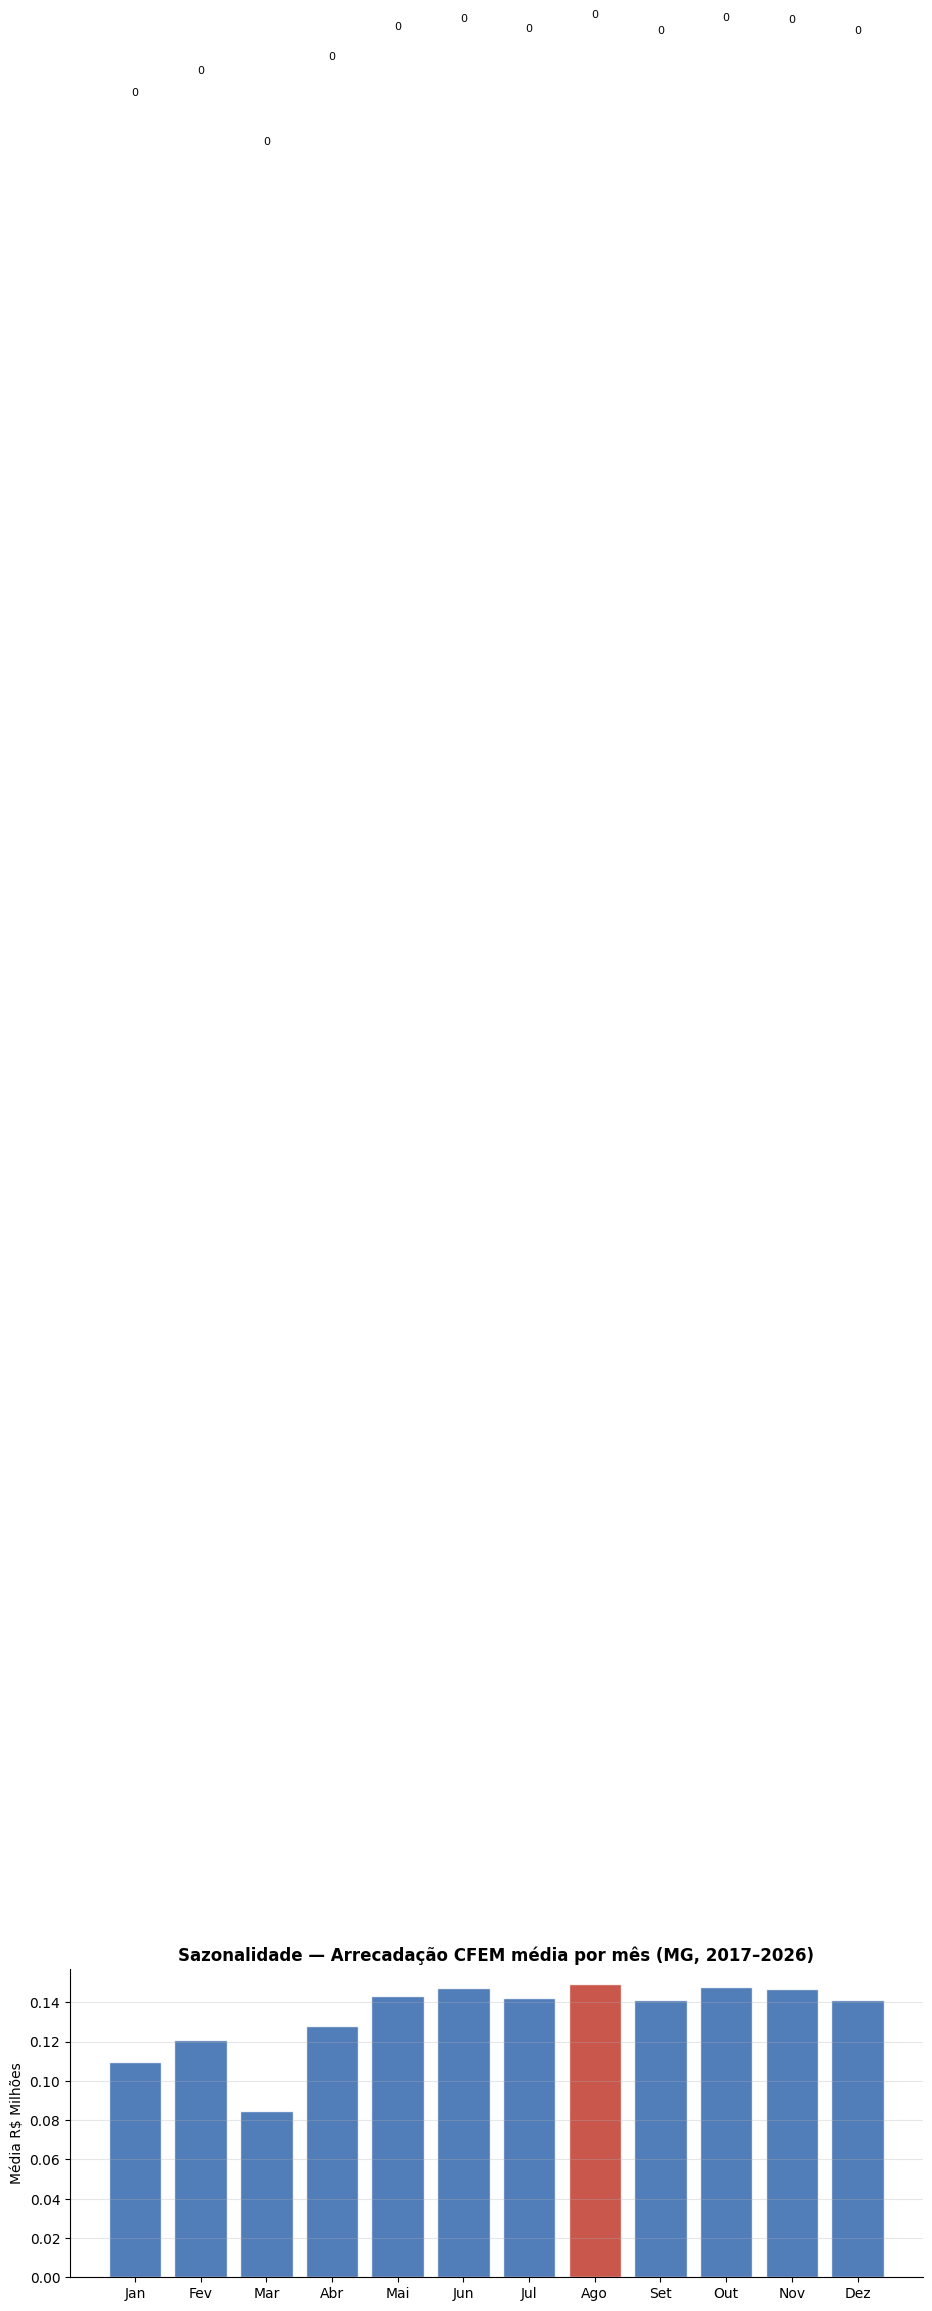

Gráfico salvo no Drive ✅


In [ ]:
sazonal = df_mg.groupby('Mês')['ValorRecolhido'].mean().reset_index()
meses   = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(11, 4))
cor_mes = ['#C0392B' if v == sazonal['ValorRecolhido'].max()
           else '#3266ad' for v in sazonal['ValorRecolhido']]
bars = ax.bar(range(1,13), sazonal['ValorRecolhido']/1e6,
              color=cor_mes, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, sazonal['ValorRecolhido']/1e6):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(1,13)); ax.set_xticklabels(meses)
ax.set_title('Sazonalidade — Arrecadação CFEM média por mês (MG, 2017–2026)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Média R$ Milhões', fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb3_sazonalidade.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


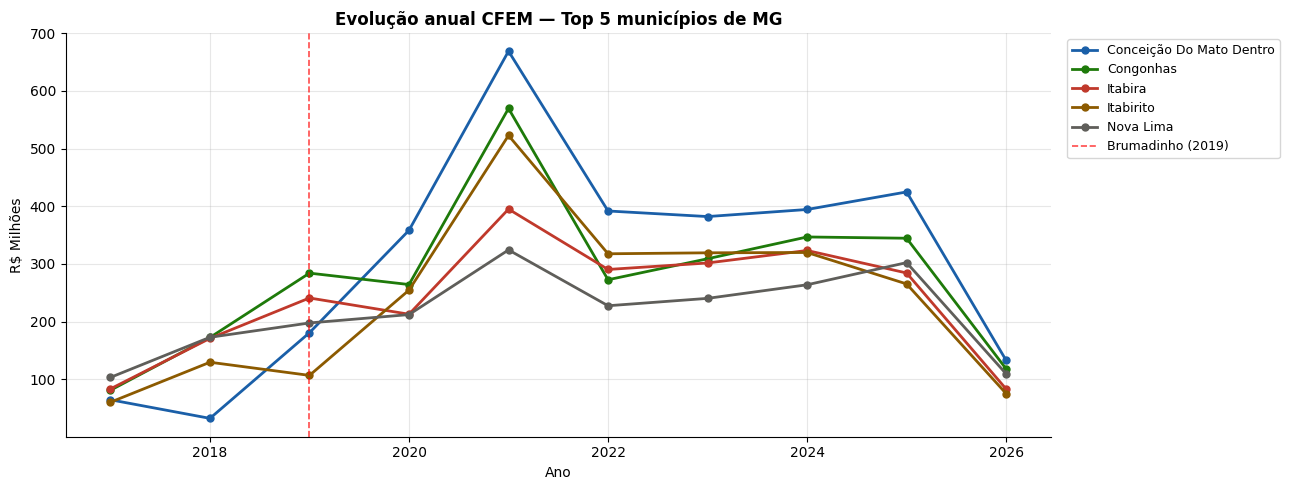

Gráfico salvo no Drive ✅


In [ ]:
top5 = (df_mg.groupby('Município')['ValorRecolhido'].sum()
             .sort_values(ascending=False).head(5).index.tolist())

pivot = (df_mg[df_mg['Município'].isin(top5)]
         .groupby(['Ano','Município'])['ValorRecolhido'].sum()
         .unstack('Município').fillna(0) / 1e6)

fig, ax = plt.subplots(figsize=(13, 5))
cores_linha = ['#1A5FA8','#1E7A0A','#C0392B','#8C5A00','#5F5E5A']

for mun, cor in zip(top5, cores_linha):
    if mun in pivot.columns:
        ax.plot(pivot.index, pivot[mun], marker='o', markersize=5,
                linewidth=2, color=cor, label=mun.title())

ax.axvline(2019, color='red', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Brumadinho (2019)')
ax.set_title('Evolução anual CFEM — Top 5 municípios de MG', fontsize=12, fontweight='bold')
ax.set_ylabel('R$ Milhões', fontsize=10); ax.set_xlabel('Ano', fontsize=10)
ax.legend(fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb3_evolucao_top5.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")
